In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.integrate as integrate

import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })
from matplotlib.colors import Normalize
import corner

from plot_eos_inference import (load_posterior, 
                                plot_mr, plot_ml, 
                                plot_pressure, 
                                plot_pop, 
                                corner_plot, 
                                get_quantiles, 
                                r14_confidence_interval, 
                                l14_confidence_interval, 
                                mtov_confidence_interval, 
                                plot_mr_nofill, plot_pop_nofill,
                                plot_ml_relative)

# load EOS
m_eos, r_eos, l_eos = np.loadtxt("../../../eos/MM_CSE_stiff/MM_CSE_MRL.dat", unpack=True, usecols=[0,1,2])
mtov = m_eos.max()
n_eos, p_eos = np.loadtxt("../../../eos/MM_CSE_stiff/MM_CSE_microscopic.dat", unpack=True)


latex_labels={"mu_1": "$\\mu_1$", "mu_2": "$\\mu_2$", "sigma_1": "$\\sigma_1$", "sigma_2": "$\\sigma_2$", "alpha": "$\\alpha$", "m_min": "$m_{\\rm{min}}$", "m_max": "$m_{\\rm{max}}$" }
fontsize=14

def pressure_confidence_interval(posterior):
    x = np.geomspace(0.5, 10, 100) # densities 
    x, quantiles, _ = get_quantiles(x, posterior["densities_EOS"] / 0.16, posterior["pressures_EOS"], posterior["weights"])

    lower = np.interp(3, x, quantiles[:, 0])
    median = np.interp(3, x, quantiles[:, 2])
    upper = np.interp(3, x, quantiles[:, 4])
    plus = upper-median
    minus = median-lower

    return f"{{{median:.0f}}}^{{+{plus:.0f}}}_{{-{minus:.0f}}}"

def confidence_interval(posterior, key):

    lower, median, upper = np.quantile(posterior[key], [0.025, 0.5, 0.975], weights=posterior["weights"], method="inverted_cdf")
    minus = median - lower
    plus = upper - median

    return f"{{{median:.2f}}}_{{-{minus:.2f}}}^{{+{plus:.2f}}}"

In [14]:
m_eos.max()


np.float64(2.1848235585741373)

In [13]:
np.interp(1.4, m_eos, l_eos)

np.float64(890.7905668425399)

## wide_ETT_stiffer

In [2]:
directory = Path("../")

posterior_gw = load_posterior(directory / "eos_inference_gw" / "outdir" / "results.h5")
posterior_mm = load_posterior(directory / "eos_inference_mm" / "outdir" / "results.h5")


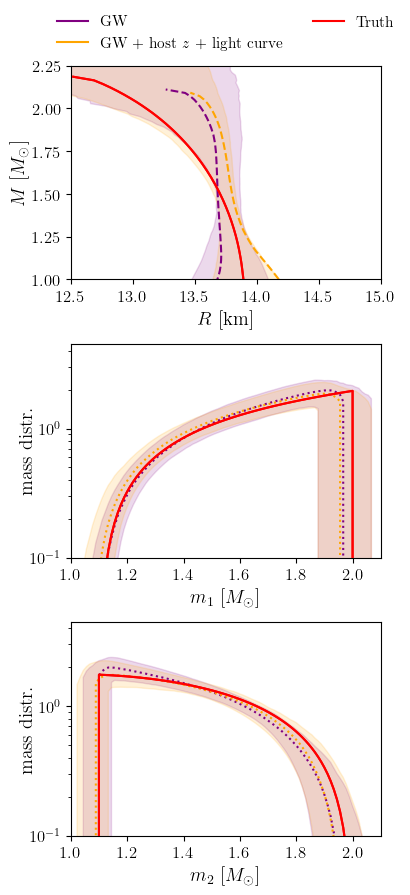

In [23]:
fig, ax = plt.subplots(3, 1, figsize=(4, 10))
fig.subplots_adjust(hspace=0.3)

plot_mr(ax[0], posterior_gw, color="purple")
plot_mr(ax[0], posterior_mm, color="orange")


#plot_ml_relative(ax[1], posterior_gw, color="purple")
#plot_ml_relative(ax[1], posterior_mm, color="orange")
#
#plot_pressure(ax[2], posterior_gw, color="purple")
#plot_pressure(ax[2], posterior_mm, color="orange")
#ax[2].set_xlim((0.5, 4))
#ax[2].set_ylim((0.1, 300))

plot_pop(ax[1:], posterior_gw, "purple")
plot_pop(ax[1:], posterior_mm, "orange")


lc1 = plt.plot([], [], color="purple")[0]
lc2 = plt.plot([], [], color="orange")[0]
lc3 = plt.plot([], [], color="red")[0]

ax[0].legend(
    [lc1, lc2, lc3], 
    ["GW", "GW + host $z$ + light curve", "Truth"], 
    fontsize=11,
    framealpha=1.,
    fancybox=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.3),
    frameon=False,
    ncol=2
)


fig.savefig("../../../figures/eos_inference_wide_ETT_stiffer.pdf", dpi=250, bbox_inches="tight")

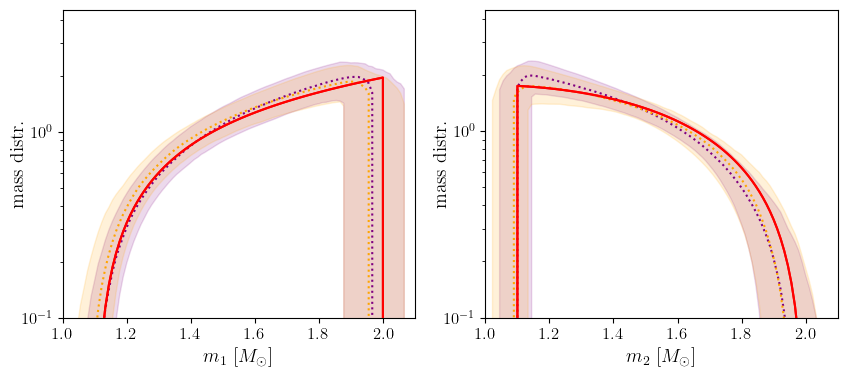

In [4]:
fig, ax = plt.subplots(1,2, figsize=(10, 4))

plot_pop(ax, posterior_gw, "purple")
plot_pop(ax, posterior_mm, "orange")

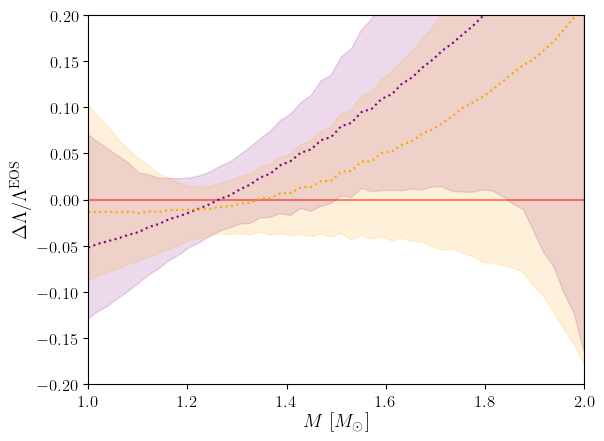

In [5]:
fig, ax = plt.subplots(1,1)

plot_ml_relative(ax, posterior_gw, "purple")
plot_ml_relative(ax, posterior_mm, "orange")

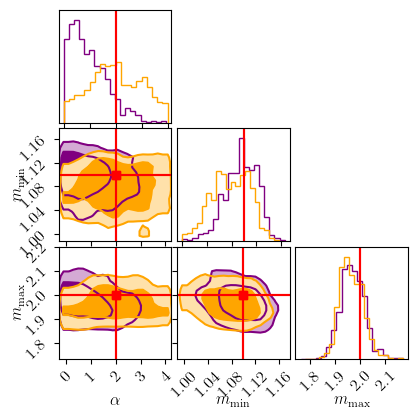

In [11]:
fig = corner_plot(posterior_gw, ["alpha", "m_min", "m_max"])
fig = corner_plot(posterior_mm, ["alpha", "m_min", "m_max"], fig, color="orange")

In [16]:
print(l14_confidence_interval(posterior_gw))
print(l14_confidence_interval(posterior_mm))

{926}^{+44}_{-51}
{897}^{+36}_{-40}


(645.933101034424, 1164.241366320676)

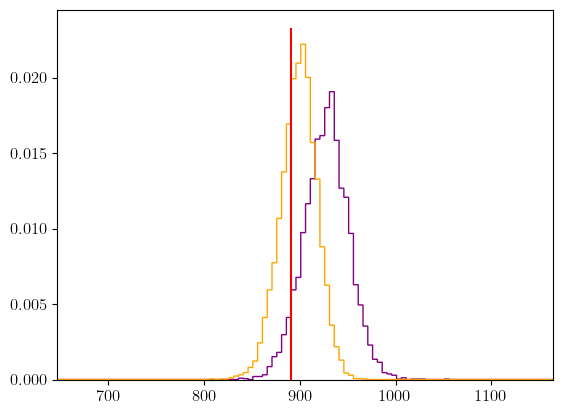

In [7]:
mx = 1.4

l14_gw = np.array([np.interp(mx, posterior_gw["masses_EOS"][j], posterior_gw["lambdas_EOS"][j]) for j in range(7000)])
l14_mm = np.array([np.interp(mx, posterior_mm["masses_EOS"][j], posterior_mm["lambdas_EOS"][j]) for j in range(7000)])


bins = np.linspace(0, 5000, 1000)
plt.hist(l14_gw, color="purple", density=True, histtype="step", bins=bins)
plt.hist(l14_mm, color="orange", density=True, histtype="step", bins=bins)

plt.vlines([np.interp(mx, m_eos, l_eos)], *plt.gca().get_ylim(), color="red")
plt.xlim((l14_mm.min()*0.8, l14_mm.max()*1.2))

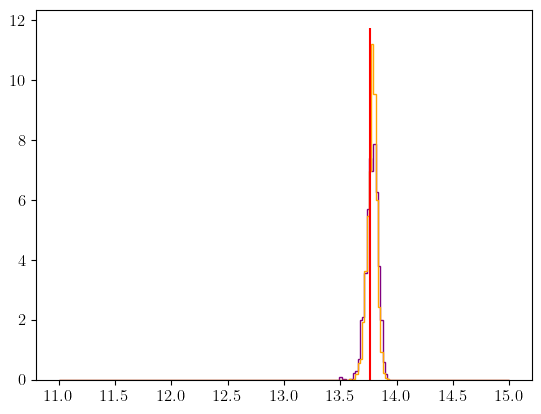

In [8]:
m_x = 1.4

r14_gw = np.array([np.interp(m_x, posterior_gw["masses_EOS"][j], posterior_gw["radii_EOS"][j]) for j in range(7000)])
r14_mm = np.array([np.interp(m_x, posterior_mm["masses_EOS"][j], posterior_mm["radii_EOS"][j]) for j in range(7000)])


bins = np.linspace(11, 15, 200)
plt.hist(r14_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(r14_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])

plt.vlines([np.interp(m_x, m_eos, r_eos)], *plt.gca().get_ylim(), color="red")


[13.22686339 14.44755753 15.40356649]


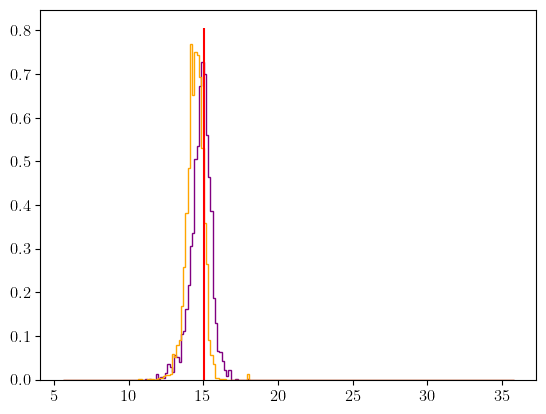

In [45]:
n_x = 1.5

p_gw = np.array([np.interp(n_x * 0.16, posterior_gw["densities_EOS"][j], posterior_gw["pressures_EOS"][j]) for j in range(7000)])
p_mm = np.array([np.interp(n_x *0.16 , posterior_mm["densities_EOS"][j], posterior_mm["pressures_EOS"][j]) for j in range(7000)])


bins = np.linspace(p_gw.min()*0.5, r14_gw.max()*2, 200)
plt.hist(p_gw, color="purple", density=True, histtype="step", bins=bins, weights=posterior_gw["weights"])
plt.hist(p_mm, color="orange", density=True, histtype="step", bins=bins, weights=posterior_mm["weights"])

plt.vlines([np.interp(n_x *0.16, n_eos, p_eos)], *plt.gca().get_ylim(), color="red")

print(np.quantile(p_mm, [0.025, 0.5, 0.975], weights=posterior_mm["weights"], method='inverted_cdf'))

In [46]:
np.interp(1.5*0.16, n_eos, p_eos)

np.float64(15.074952458435956)

(0.0, 6.0)

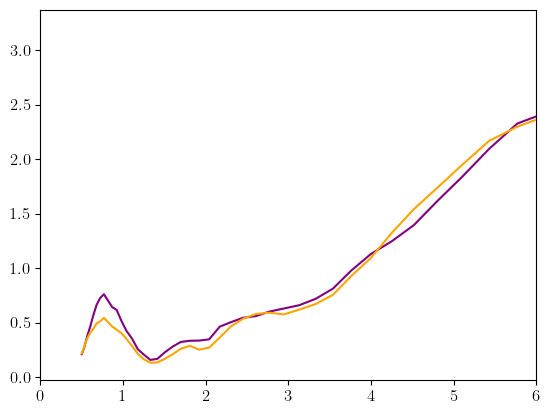

In [39]:
xs, quantiles, _ = get_quantiles(np.geomspace(0.5, 10, 50), posterior_gw["densities_EOS"]/0.16, posterior_gw["pressures_EOS"], posterior_gw["weights"])
xs, quantiles_mm, _ = get_quantiles(np.geomspace(0.5, 10, 50), posterior_mm["densities_EOS"]/0.16, posterior_mm["pressures_EOS"], posterior_mm["weights"])

plt.plot(xs, (quantiles[:, 4] / quantiles[:, 0])-1, color="purple")
plt.plot(xs, (quantiles_mm[:, 4] / quantiles_mm[:, 0])-1, color="orange")
plt.xlim((0, 6))

In [29]:
confidence_interval(posterior_mm, "alpha")

'{1.93}_{-1.76}^{+1.87}'

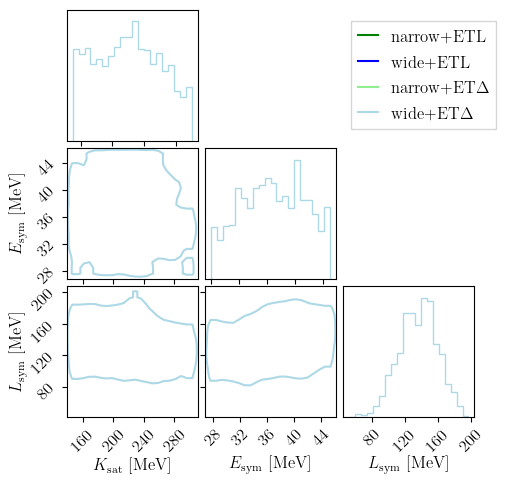

In [10]:
fig, ax = plt.subplots(3, 3, figsize=(5,5))

corner_plot(posterior_mm, parameter_names=['K_sat', 'E_sym', 'L_sym'], fig=fig, color="lightblue", fill_contours=False, levels=[0.95])

lc1 = plt.plot([], [], color="green")[0]
lc2 = plt.plot([], [], color="blue")[0]
lc3 = plt.plot([], [], color="lightgreen")[0]
lc4 = plt.plot([], [], color="lightblue")[0]
ax[0, -1].legend(
    [lc1, lc2, lc3, lc4], 
    ["narrow+ETL", "wide+ETL", "narrow+ET$\\Delta$", "wide+ET$\\Delta$"], 
    handlelength=1.2, handleheight=1.2, fontsize=12,
    loc='center left', frameon=True, fancybox=False, ncol=1
)


In [13]:
events = pd.read_csv("../events.dat", sep=" ")